
# Modelo Fourier — análise morfométrica e análise setorial 3×3

Notebook reconstruído do zero com base na lógica do código Fourier utilizado anteriormente.

O fluxo foi organizado para evitar os problemas encontrados nas versões anteriores:

1. configuração central;
2. carregamento e validação da máscara;
3. individualização dos grãos;
4. perfil radial;
5. série de Fourier;
6. seleção dos harmônicos;
7. descritores geométricos e espectrais;
8. auditoria dos resultados;
9. divisão espacial **3×3**;
10. análise estatística por setor;
11. mapas e visualizações;
12. comparação com a análise convencional da Faro 12;
13. exportação CSV/Excel/PNG/PDF.

A grade espacial é definida pela **dimensão total da máscara**, e não pelos limites dos centroides.


In [46]:

# ============================================================
# 1. IMPORTAÇÕES E CONFIGURAÇÃO
# ============================================================

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from scipy.fft import fft, ifft
from scipy.ndimage import label, center_of_mass
from scipy.interpolate import CubicSpline

from skimage.measure import regionprops
from skimage.morphology import convex_hull_image

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from matplotlib.backends.backend_pdf import PdfPages

warnings.filterwarnings("ignore")

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

CONFIG = {
    # Máscara utilizada anteriormente pelo modelo Fourier.
    "mask_path": "/home/victor/analise_sinais_2025/joelson/1GU2PA/saida_segmentacao_graos/axes_individuais/08_graos_binaria_sem_borda_com_lacuna.png",

    # Mantido igual ao código original.
    # Se a calibração correta for outra, altere aqui e
    # execute novamente TODO o notebook.
    "px_to_um": 1.0,

    # Componentes menores que este valor serão ignorados.
    "min_grain_pixels": 10,

    # Perfil radial.
    "num_angles": 360,

    # Busca dos harmônicos.
    "min_harmonics": 1,
    "max_harmonics": 200,

    # Descritores Fourier.
    "n_fourier_descriptors": 64,

    # Pontos usados apenas para visualização contínua.
    "smooth_points": 500,

    # Bandas utilizadas no código anterior.
    "roughness_bands": {
        "low": (1, 15),
        "medium": (16, 60),
        "high": (61, 180),
    },

    "output_dir": "resultados_fourier_setorial",
}

OUTPUT_DIR = Path(CONFIG["output_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Configuração carregada.")
print("Máscara:", CONFIG["mask_path"])
print("Saída:", OUTPUT_DIR.resolve())


Configuração carregada.
Máscara: /home/victor/analise_sinais_2025/joelson/1GU2PA/saida_segmentacao_graos/axes_individuais/08_graos_binaria_sem_borda_com_lacuna.png
Saída: /home/victor/analise_sinais_2025/joelson/2LFST1AM/projeto/resultados_fourier_setorial


Shape original: (1281, 1710)
Tipo: uint8

Máscara final:
  Dimensão: (1281, 1710)
  Pixels de grão: 613052
  Ocupação: 27.987%


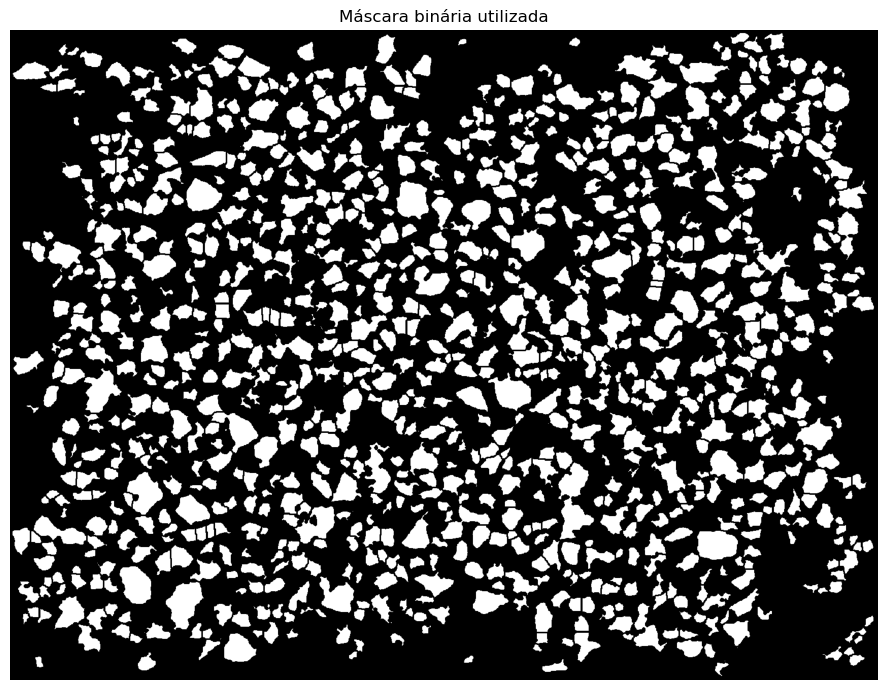

In [47]:

# ============================================================
# 2. CARREGAMENTO E VALIDAÇÃO DA MÁSCARA
# ============================================================

mask_path = Path(CONFIG["mask_path"])

if not mask_path.exists():
    raise FileNotFoundError(
        f"\nMáscara não encontrada:\n{mask_path}\n\n"
        "Altere CONFIG['mask_path'] na célula anterior."
    )

raw = np.array(Image.open(mask_path))

print("Shape original:", raw.shape)
print("Tipo:", raw.dtype)

if raw.ndim == 2:
    mask = raw > 0

elif raw.ndim == 3:
    if raw.shape[2] == 4:
        raw = raw[:, :, :3]
    mask = np.any(raw > 0, axis=2)

else:
    raise ValueError(f"Formato não suportado: {raw.shape}")

mask = np.asarray(mask, dtype=bool)

height, width = mask.shape

if mask.sum() == 0:
    raise ValueError("A máscara não possui pixels de grão.")

print("\nMáscara final:")
print("  Dimensão:", mask.shape)
print("  Pixels de grão:", int(mask.sum()))
print("  Ocupação:", f"{mask.mean()*100:.3f}%")

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(mask, cmap="gray", origin="upper")
ax.set_title("Máscara binária utilizada")
ax.axis("off")
plt.tight_layout()
plt.show()


Componentes conectados detectados: 1078
Grãos válidos: 949
Área dos grãos — mínimo: 10 | média: 645.69 | máximo: 5306


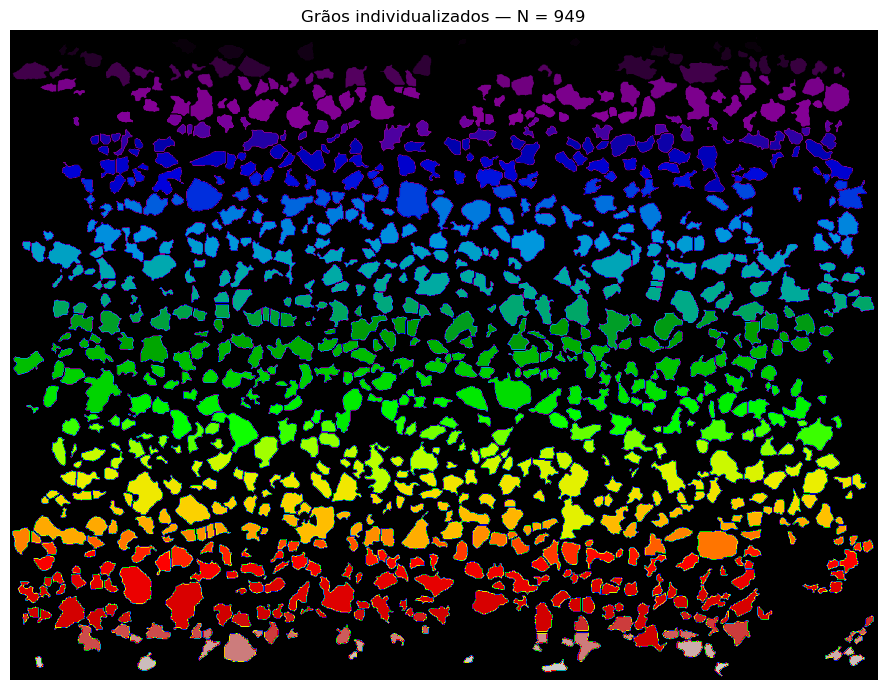

In [48]:

# ============================================================
# 3. INDIVIDUALIZAÇÃO DOS GRÃOS
# ============================================================

labels_array, detected_labels = label(mask)

valid_ids = []

for old_id in range(1, detected_labels + 1):
    n_pixels = int(np.sum(labels_array == old_id))
    if n_pixels >= CONFIG["min_grain_pixels"]:
        valid_ids.append(old_id)

if not valid_ids:
    raise ValueError("Nenhum grão passou pelo filtro de tamanho.")

# Reindexação contínua dos rótulos.
clean_labels = np.zeros_like(labels_array, dtype=np.int32)

for new_id, old_id in enumerate(valid_ids, start=1):
    clean_labels[labels_array == old_id] = new_id

labels_array = clean_labels
num_grains = len(valid_ids)

sizes = np.bincount(labels_array.ravel())[1:]

print("Componentes conectados detectados:", detected_labels)
print("Grãos válidos:", num_grains)
print(
    "Área dos grãos — mínimo:",
    sizes.min(),
    "| média:",
    f"{sizes.mean():.2f}",
    "| máximo:",
    sizes.max()
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(labels_array, cmap="nipy_spectral", origin="upper")
ax.set_title(f"Grãos individualizados — N = {num_grains}")
ax.axis("off")
plt.tight_layout()
plt.show()


In [49]:

# ============================================================
# 4. FUNÇÕES MATEMÁTICAS
# ============================================================

def calculate_radii(region, center, num_angles=360, px_to_um=1.0):
    """
    Calcula o perfil radial a partir do centro de massa.
    Convenção do centro: (y, x).
    """

    angles = np.linspace(
        0, 2*np.pi, num_angles, endpoint=False
    )

    radii = np.empty(num_angles, dtype=float)

    y0, x0 = center
    max_radius = max(region.shape) * 2

    for i, angle in enumerate(angles):

        found = False

        for r in range(1, max_radius + 1):

            x = int(round(x0 + r*np.cos(angle)))
            y = int(round(y0 + r*np.sin(angle)))

            if (
                x < 0 or y < 0 or
                x >= region.shape[1] or
                y >= region.shape[0]
            ):
                radii[i] = r * px_to_um
                found = True
                break

            if not region[y, x]:
                radii[i] = r * px_to_um
                found = True
                break

        if not found:
            radii[i] = max_radius * px_to_um

    return angles, radii


def fourier_series(radii, num_harmonics):
    """Reconstrói o perfil radial usando os harmônicos selecionados."""

    coeffs = fft(radii)
    filtered = np.zeros_like(coeffs, dtype=complex)

    filtered[0] = coeffs[0]

    h = min(
        int(num_harmonics),
        len(radii)//2
    )

    if h > 0:
        filtered[1:h+1] = coeffs[1:h+1]
        filtered[-h:] = coeffs[-h:]

    return np.real(ifft(filtered))


def calculate_fourier_descriptors(radii, n_descriptors=64):
    """Calcula amplitudes espectrais normalizadas pelo número de amostras."""

    coeffs = fft(radii)
    desc = np.abs(coeffs) / len(coeffs)

    return desc[:min(n_descriptors, len(desc))]


def calculate_roughness_coefficients(coeffs, j, k):
    """P_jk = sqrt(0.5 * sum(a_n² + b_n²))."""

    j = max(0, int(j))
    k = min(len(coeffs)-1, int(k))

    if j > k:
        return 0.0

    a = np.real(coeffs[j:k+1])
    b = np.imag(coeffs[j:k+1])

    return float(np.sqrt(0.5*np.sum(a*a + b*b)))


def calculate_geometric_descriptors(region):
    """
    Retorna:
        roundness,
        circularity,
        regularity
    """

    props = regionprops(
        region.astype(np.uint8)
    )[0]

    area = float(props.area)
    perimeter = float(props.perimeter)

    if perimeter <= 0:
        return 0.0, 0.0, 0.0

    circularity = (
        4*np.pi*area
    ) / (
        perimeter**2
    )

    convex = convex_hull_image(region)

    convex_props = regionprops(
        convex.astype(np.uint8)
    )[0]

    convex_perimeter = float(
        convex_props.perimeter
    )

    if perimeter > convex_perimeter:
        regularity = np.log(
            perimeter /
            (perimeter - convex_perimeter)
        )
    else:
        regularity = 0.0

    equivalent_radius = np.sqrt(
        area/np.pi
    )

    roundness = (
        equivalent_radius /
        (perimeter/(2*np.pi))
    )

    return (
        float(roundness),
        float(circularity),
        float(regularity)
    )


print("Funções matemáticas definidas.")


Funções matemáticas definidas.


In [50]:

# ============================================================
# 5. PROCESSAMENTO FOURIER DE TODOS OS GRÃOS
# ============================================================

def analyze_grains(labels_array, num_grains, config):

    px_to_um = float(config["px_to_um"])
    num_angles = int(config["num_angles"])
    min_h = int(config["min_harmonics"])
    max_h = int(config["max_harmonics"])

    results = []

    for grain_id in range(1, num_grains + 1):

        region = labels_array == grain_id
        n_pixels = int(region.sum())

        if n_pixels < config["min_grain_pixels"]:
            continue

        center = center_of_mass(region)

        area_um2 = n_pixels * px_to_um**2

        angles, radii = calculate_radii(
            region,
            center,
            num_angles=num_angles,
            px_to_um=px_to_um
        )

        best_h = min_h
        best_mse = np.inf
        best_r2 = -np.inf
        best_reconstruction = None

        for h in range(min_h, max_h + 1):

            reconstruction = fourier_series(
                radii,
                h
            )

            mse = mean_squared_error(
                radii,
                reconstruction
            )

            r2 = r2_score(
                radii,
                reconstruction
            )

            if mse < best_mse:
                best_h = h
                best_mse = float(mse)
                best_r2 = float(r2)
                best_reconstruction = reconstruction.copy()

        mae = mean_absolute_error(
            radii,
            best_reconstruction
        )

        coeffs = fft(radii)
        bands = config["roughness_bands"]

        p_low = calculate_roughness_coefficients(
            coeffs, *bands["low"]
        )
        p_medium = calculate_roughness_coefficients(
            coeffs, *bands["medium"]
        )
        p_high = calculate_roughness_coefficients(
            coeffs, *bands["high"]
        )

        fourier_desc = calculate_fourier_descriptors(
            radii,
            config["n_fourier_descriptors"]
        )

        roundness, circularity, regularity = (
            calculate_geometric_descriptors(region)
        )

        smooth_angles = np.linspace(
            0,
            2*np.pi,
            config["smooth_points"]
        )

        periodic_angles = np.r_[angles, 2*np.pi]
        periodic_real = np.r_[radii, radii[0]]
        periodic_fourier = np.r_[
            best_reconstruction,
            best_reconstruction[0]
        ]

        cs_real = CubicSpline(
            periodic_angles,
            periodic_real
        )

        cs_fourier = CubicSpline(
            periodic_angles,
            periodic_fourier
        )

        results.append({
            "grain_id": grain_id,
            "center_y_px": float(center[0]),
            "center_x_px": float(center[1]),
            "area_px2": n_pixels,
            "area_um2": area_um2,
            "mae_um": float(mae),
            "mse_um2": float(best_mse),
            "r2": float(best_r2),
            "optimal_harmonics": int(best_h),
            "roughness_low": float(p_low),
            "roughness_medium": float(p_medium),
            "roughness_high": float(p_high),
            "roughness_medium_low_ratio": (
                float(p_medium/p_low) if p_low > 0 else 0.0
            ),
            "roughness_high_low_ratio": (
                float(p_high/p_low) if p_low > 0 else 0.0
            ),
            "roundness": float(roundness),
            "circularity": float(circularity),
            "regularity": float(regularity),
            "angles": angles,
            "radii": radii,
            "angles_smooth": smooth_angles,
            "radii_smooth": cs_real(smooth_angles),
            "radii_fourier": cs_fourier(smooth_angles),
            "fourier_descriptors": fourier_desc,
        })

        if grain_id % 10 == 0 or grain_id == num_grains:
            print(f"Processados: {grain_id}/{num_grains}")

    if not results:
        raise RuntimeError("Nenhum grão foi processado.")

    return results


results = analyze_grains(
    labels_array,
    num_grains,
    CONFIG
)

df = pd.DataFrame(results)

print("\n" + "="*70)
print("ANÁLISE FOURIER CONCLUÍDA")
print("="*70)
print("Grãos analisados:", len(df))


Processados: 10/949
Processados: 20/949
Processados: 30/949
Processados: 40/949
Processados: 50/949
Processados: 60/949
Processados: 70/949
Processados: 80/949
Processados: 90/949
Processados: 100/949
Processados: 110/949
Processados: 120/949
Processados: 130/949
Processados: 140/949
Processados: 150/949
Processados: 160/949
Processados: 170/949
Processados: 180/949
Processados: 190/949
Processados: 200/949
Processados: 210/949
Processados: 220/949
Processados: 230/949
Processados: 240/949
Processados: 250/949
Processados: 260/949
Processados: 270/949
Processados: 280/949
Processados: 290/949
Processados: 300/949
Processados: 310/949
Processados: 320/949
Processados: 330/949
Processados: 340/949
Processados: 350/949
Processados: 360/949
Processados: 370/949
Processados: 380/949
Processados: 390/949
Processados: 400/949
Processados: 410/949
Processados: 420/949
Processados: 430/949
Processados: 440/949
Processados: 450/949
Processados: 460/949
Processados: 470/949
Processados: 480/949
P

In [51]:

# ============================================================
# 6. AUDITORIA DOS RESULTADOS FOURIER
# ============================================================

required_columns = [
    "grain_id",
    "center_y_px",
    "center_x_px",
    "area_px2",
    "area_um2",
    "mae_um",
    "mse_um2",
    "r2",
    "optimal_harmonics",
    "roughness_low",
    "roughness_medium",
    "roughness_high",
    "roundness",
    "circularity",
    "regularity",
]

missing = [
    c for c in required_columns
    if c not in df.columns
]

if missing:
    raise RuntimeError(
        f"Colunas ausentes: {missing}"
    )

if df["grain_id"].duplicated().any():
    raise RuntimeError("IDs de grão duplicados.")

if df[required_columns].isna().any().any():
    raise RuntimeError(
        "Existem valores NaN nos descritores principais."
    )

inside = (
    (df["center_x_px"] >= 0) &
    (df["center_x_px"] < width) &
    (df["center_y_px"] >= 0) &
    (df["center_y_px"] < height)
)

if not inside.all():
    raise RuntimeError(
        "Existe centroide fora da imagem."
    )

print("✓ IDs únicos")
print("✓ Sem NaN")
print("✓ Centroides dentro da imagem")
print("✓ Resultados Fourier validados")

display(
    df[required_columns]
    .head(10)
    .round(5)
)


✓ IDs únicos
✓ Sem NaN
✓ Centroides dentro da imagem
✓ Resultados Fourier validados


,grain_id,center_y_px,center_x_px,area_px2,area_um2,mae_um,mse_um2,r2,optimal_harmonics,roughness_low,roughness_medium,roughness_high,roundness,circularity,regularity
0,1,15.66595,1437.71767,464,464.0,0.0,0.0,1.0,180,681.19447,79.33565,45.71593,0.78515,0.61646,3.45531
1,2,22.16956,1508.99866,749,749.0,0.0,0.0,1.0,180,553.53066,115.71051,70.54708,0.67917,0.46127,1.95720
2,3,37.43593,739.14983,1475,1475.0,0.0,0.0,1.0,180,920.86685,87.36592,62.34130,0.78108,0.61009,2.76234
3,4,31.34381,1463.97782,541,541.0,0.0,0.0,1.0,180,698.12538,117.44821,71.31530,0.69805,0.48727,2.79662
4,5,23.62810,1112.55785,242,242.0,0.0,0.0,1.0,180,214.13331,56.68220,31.54446,0.92374,0.85329,4.62411
5,6,30.63469,345.03075,813,813.0,0.0,0.0,1.0,180,655.72559,122.06291,48.66820,0.76443,0.58435,2.86764
6,7,22.85714,891.03759,133,133.0,0.0,0.0,1.0,180,248.23237,61.31962,33.35560,0.89739,0.80531,0.00000
7,8,31.75000,1392.97500,200,200.0,0.0,0.0,1.0,180,249.00586,64.00769,36.59371,0.80936,0.65506,3.05155
8,9,43.16545,583.80657,822,822.0,0.0,0.0,1.0,180,394.70886,58.34879,43.63866,0.85894,0.73777,4.42687
9,10,39.25668,104.08556,187,187.0,0.0,0.0,1.0,180,317.16212,69.64833,39.46263,0.80043,0.64069,3.01698


In [52]:

# ============================================================
# 7. DIVISÃO ESPACIAL 3 × 3
# ============================================================

# Limites calculados sobre a imagem inteira.
x1 = width / 3.0
x2 = 2.0 * width / 3.0
y1 = height / 3.0
y2 = 2.0 * height / 3.0

sector_order = [
    "NW", "N", "NE",
    "W", "C", "E",
    "SW", "S", "SE"
]


def classify_sector(x, y):

    if x < x1:
        col = "W"
    elif x < x2:
        col = "C"
    else:
        col = "E"

    if y < y1:
        row = "N"
    elif y < y2:
        row = "C"
    else:
        row = "S"

    return {
        ("N", "W"): "NW",
        ("N", "C"): "N",
        ("N", "E"): "NE",
        ("C", "W"): "W",
        ("C", "C"): "C",
        ("C", "E"): "E",
        ("S", "W"): "SW",
        ("S", "C"): "S",
        ("S", "E"): "SE",
    }[(row, col)]


df["Setor"] = [
    classify_sector(x, y)
    for x, y in zip(
        df["center_x_px"],
        df["center_y_px"]
    )
]

df["Setor"] = pd.Categorical(
    df["Setor"],
    categories=sector_order,
    ordered=True
)

if df["Setor"].isna().any():
    raise RuntimeError("Existe grão sem setor.")

sector_counts = (
    df.groupby(
        "Setor",
        observed=False
    )
    .size()
    .reindex(
        sector_order,
        fill_value=0
    )
)

if int(sector_counts.sum()) != len(df):
    raise RuntimeError(
        "A soma dos setores não coincide com o total."
    )

print("="*70)
print("AUDITORIA DA GRADE 3 × 3")
print("="*70)
print("Total de grãos:", len(df))
print("Total nos nove setores:", int(sector_counts.sum()))

display(
    sector_counts
    .rename("N_grãos")
    .to_frame()
)


AUDITORIA DA GRADE 3 × 3
Total de grãos: 949
Total nos nove setores: 949


,N_grãos
Setor,
NW,96
N,101
NE,104
W,108
C,127
E,104
SW,106
S,102
SE,101


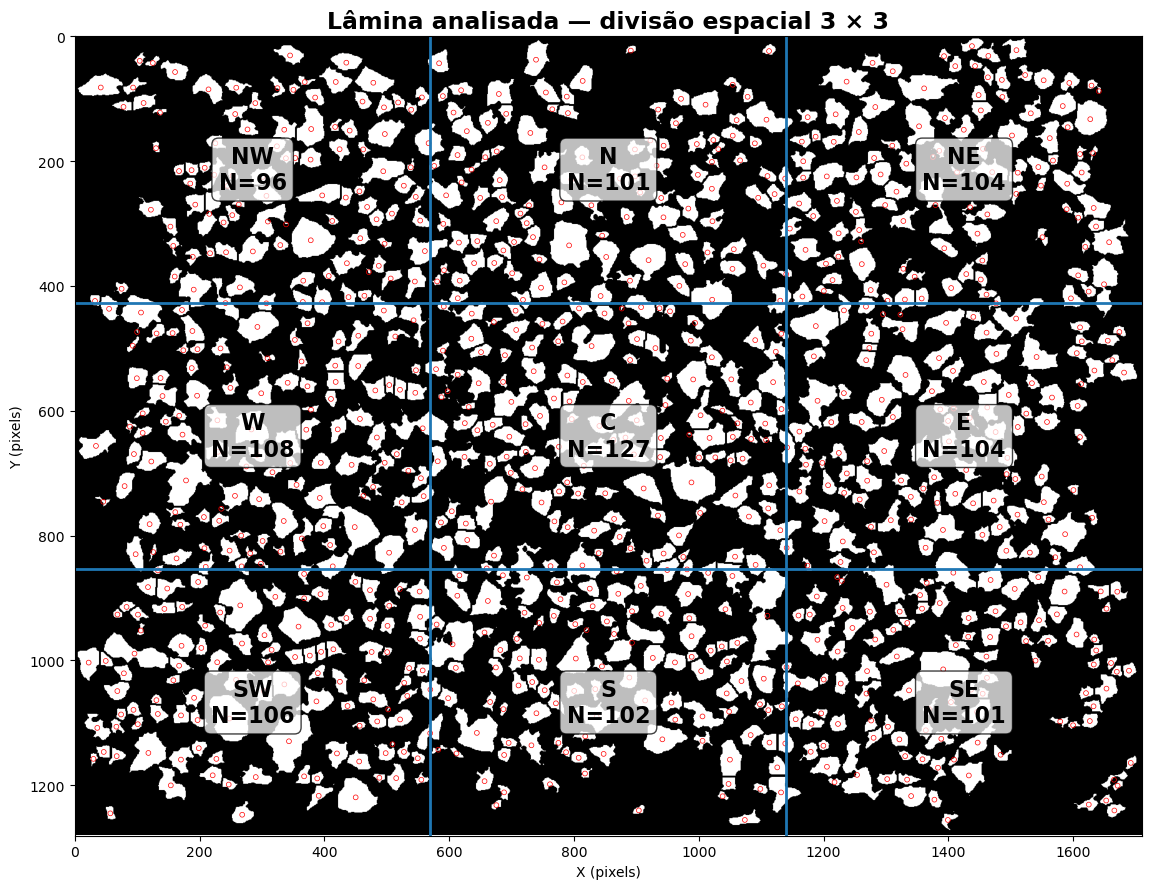

Figura salva: resultados_fourier_setorial/lamina_grade_3x3.png


In [53]:

# ============================================================
# 8. LÂMINA + GRADE + CENTROIDES
# ============================================================

fig, ax = plt.subplots(figsize=(14, 9))

ax.imshow(
    mask,
    cmap="gray",
    origin="upper"
)

ax.axvline(x1, linewidth=2)
ax.axvline(x2, linewidth=2)
ax.axhline(y1, linewidth=2)
ax.axhline(y2, linewidth=2)

ax.scatter(
    df["center_x_px"],
    df["center_y_px"],
    s=12,
    facecolors="none",
    edgecolors="red",
    linewidths=0.5
)

positions = {
    "NW": (x1/2, y1/2),
    "N": ((x1+x2)/2, y1/2),
    "NE": ((x2+width)/2, y1/2),
    "W": (x1/2, (y1+y2)/2),
    "C": ((x1+x2)/2, (y1+y2)/2),
    "E": ((x2+width)/2, (y1+y2)/2),
    "SW": (x1/2, (y2+height)/2),
    "S": ((x1+x2)/2, (y2+height)/2),
    "SE": ((x2+width)/2, (y2+height)/2),
}

for sector, (sx, sy) in positions.items():

    n = int(sector_counts.loc[sector])

    ax.text(
        sx,
        sy,
        f"{sector}\nN={n}",
        ha="center",
        va="center",
        fontsize=16,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.75
        )
    )

ax.set_xlim(0, width)
ax.set_ylim(height, 0)
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")
ax.set_title(
    "Lâmina analisada — divisão espacial 3 × 3",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout()

grid_path = OUTPUT_DIR / "lamina_grade_3x3.png"
fig.savefig(grid_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figura salva:", grid_path)


In [54]:

# ============================================================
# 9. ESTATÍSTICA SETORIAL
# ============================================================

numeric_columns = [
    "area_um2",
    "mae_um",
    "mse_um2",
    "r2",
    "optimal_harmonics",
    "roughness_low",
    "roughness_medium",
    "roughness_high",
    "roundness",
    "circularity",
    "regularity",
]

sector_stats = {}

for col in numeric_columns:

    sector_stats[col] = (
        df.groupby(
            "Setor",
            observed=False
        )[col]
        .agg(
            N="count",
            Media="mean",
            Mediana="median",
            Desvio_padrao="std",
            Minimo="min",
            Maximo="max"
        )
        .reindex(sector_order)
    )

sector_mean = pd.DataFrame(
    index=sector_order
)

sector_mean.index.name = "Setor"
sector_mean["N"] = sector_counts.astype(int)
sector_mean["Fração (%)"] = (
    sector_mean["N"] / len(df) * 100
)

names = {
    "area_um2": "Área média (µm²)",
    "mae_um": "MAE médio (µm)",
    "mse_um2": "MSE médio (µm²)",
    "r2": "R² médio",
    "optimal_harmonics": "Harmônicos médios",
    "roughness_low": "Rugosidade baixa",
    "roughness_medium": "Rugosidade média",
    "roughness_high": "Rugosidade alta",
    "roundness": "Roundness média",
    "circularity": "Circularidade média",
    "regularity": "Regularidade média",
}

for col, name in names.items():
    sector_mean[name] = sector_stats[col]["Media"]

print("="*70)
print("TABELA SETORIAL — MÉDIAS")
print("="*70)

display(
    sector_mean.round(4)
)

sector_mean.to_csv(
    OUTPUT_DIR / "tabela_setorial_medias.csv",
    encoding="utf-8-sig"
)


TABELA SETORIAL — MÉDIAS


,N,Fração (%),Área média (µm²),MAE médio (µm),MSE médio (µm²),R² médio,Harmônicos médios,Rugosidade baixa,Rugosidade média,Rugosidade alta,Roundness média,Circularidade média,Regularidade média
Setor,,,,,,,,,,,,,
NW,96,10.1159,616.7292,0.0,0.0,1.0,179.9167,546.5154,90.3968,51.7950,0.8033,0.6539,3.0462
N,101,10.6428,658.5050,0.0,0.0,1.0,179.9208,534.3104,83.8953,50.1209,0.8043,0.6539,3.1629
NE,104,10.9589,639.3462,0.0,0.0,1.0,179.9135,562.6432,93.2861,53.9391,0.7921,0.6388,2.7248
W,108,11.3804,670.3333,0.0,0.0,1.0,179.8981,582.9596,92.9248,53.1027,0.7727,0.6090,2.8846
C,127,13.3825,626.2283,0.0,0.0,1.0,179.8976,570.5932,87.7437,50.8378,0.8001,0.6488,3.1691
E,104,10.9589,685.6250,0.0,0.0,1.0,179.9135,570.6608,95.0424,54.9601,0.7918,0.6350,3.1866
SW,106,11.1697,659.0849,0.0,0.0,1.0,179.8774,534.1393,84.8396,49.7760,0.8085,0.6643,2.8445
S,102,10.7482,692.0196,0.0,0.0,1.0,176.4118,554.7305,87.2487,51.1008,0.7910,0.6385,3.4952
SE,101,10.6428,563.0990,0.0,0.0,1.0,178.0990,552.0965,90.1871,51.5924,0.7867,0.6305,3.4500


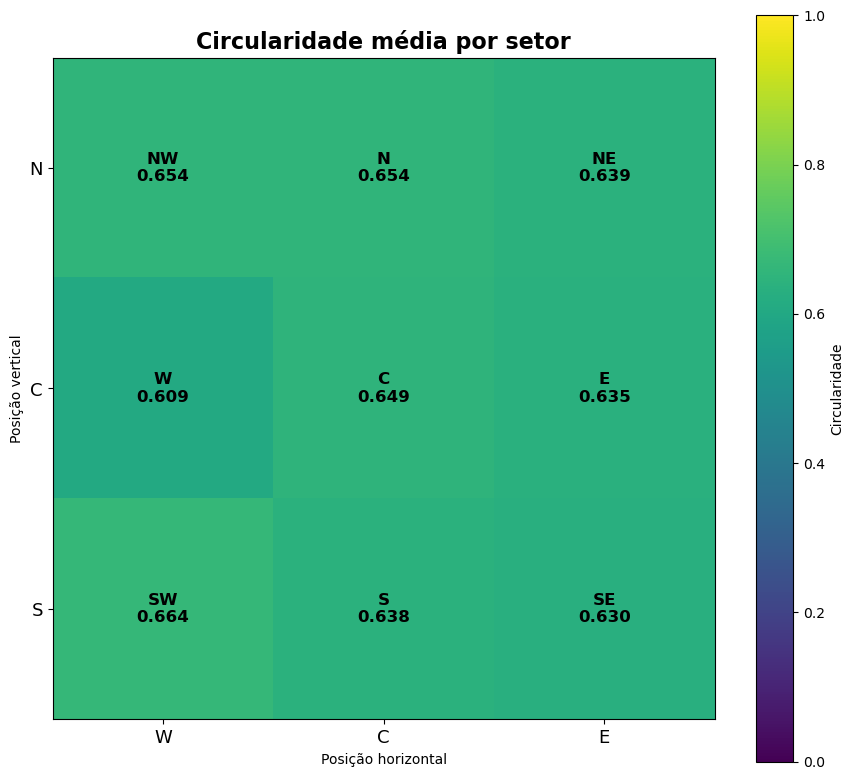

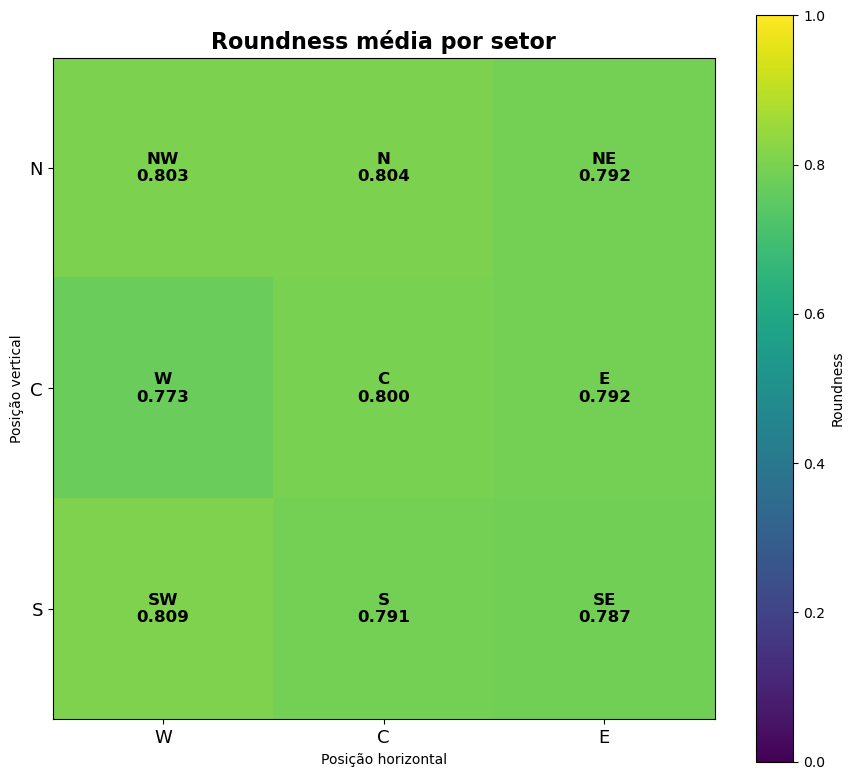

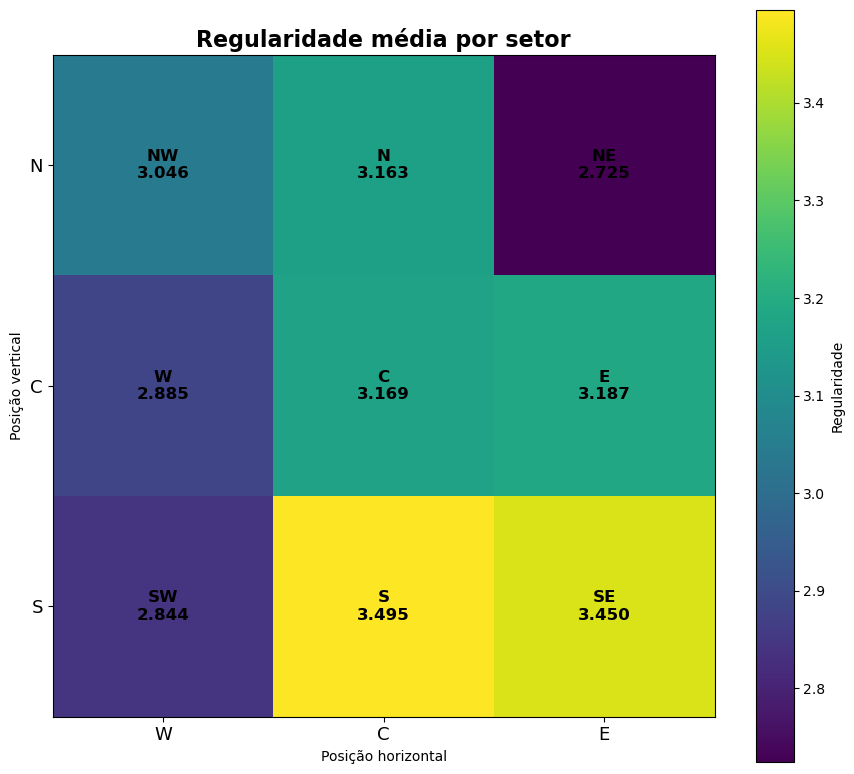

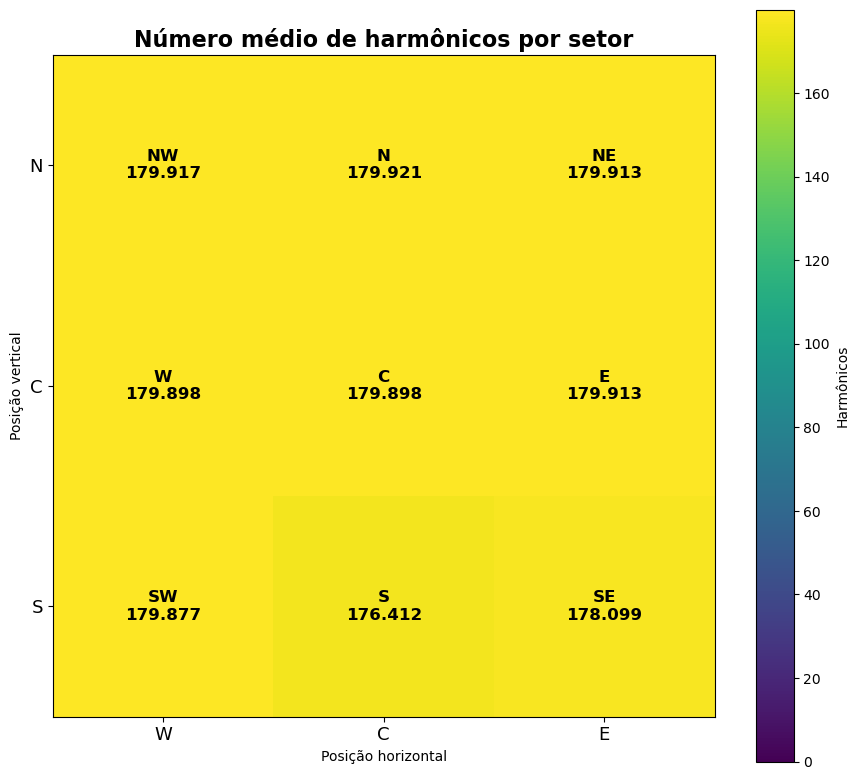

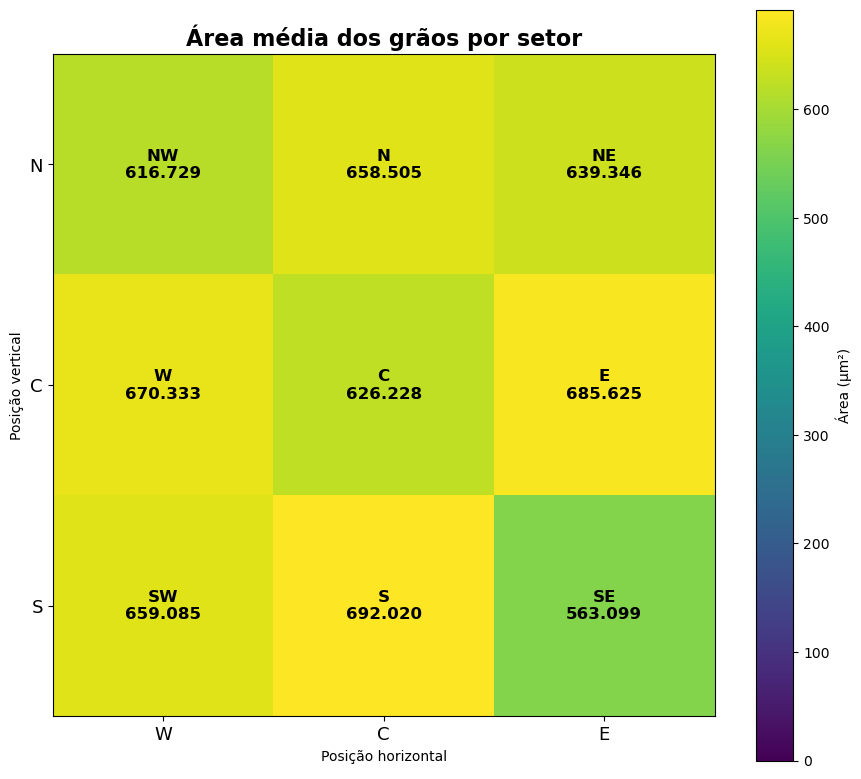

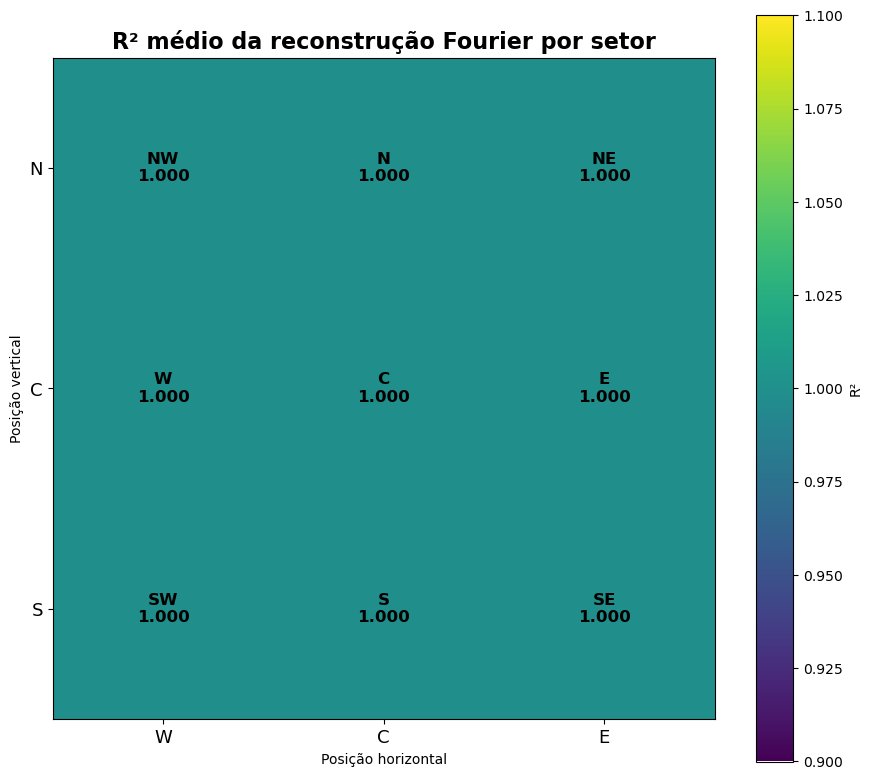

PosixPath('resultados_fourier_setorial/mapa_r2.png')

In [55]:

# ============================================================
# 10. MAPAS DOS DESCRITORES
# ============================================================

def sector_matrix(series):

    return np.array([
        [series.loc["NW"], series.loc["N"], series.loc["NE"]],
        [series.loc["W"],  series.loc["C"], series.loc["E"]],
        [series.loc["SW"], series.loc["S"], series.loc["SE"]],
    ], dtype=float)


def plot_sector_map(
    table,
    column,
    title,
    label,
    filename,
    vmin=None,
    vmax=None
):

    matrix = sector_matrix(
        table[column]
    )

    fig, ax = plt.subplots(
        figsize=(9, 8)
    )

    im = ax.imshow(
        matrix,
        interpolation="nearest",
        aspect="equal",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["W", "C", "E"], fontsize=13)

    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(["N", "C", "S"], fontsize=13)

    ax.set_xlabel("Posição horizontal")
    ax.set_ylabel("Posição vertical")
    ax.set_title(title, fontsize=16, fontweight="bold")

    labels = [
        ["NW", "N", "NE"],
        ["W", "C", "E"],
        ["SW", "S", "SE"],
    ]

    for i in range(3):
        for j in range(3):

            value = matrix[i, j]

            text = (
                f"{value:.3f}"
                if np.isfinite(value)
                else "—"
            )

            ax.text(
                j,
                i,
                f"{labels[i][j]}\n{text}",
                ha="center",
                va="center",
                fontsize=12,
                fontweight="bold"
            )

    fig.colorbar(
        im,
        ax=ax,
        label=label
    )

    plt.tight_layout()

    path = OUTPUT_DIR / filename

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return path


plot_sector_map(
    sector_mean,
    "Circularidade média",
    "Circularidade média por setor",
    "Circularidade",
    "mapa_circularidade.png",
    0,
    1
)

plot_sector_map(
    sector_mean,
    "Roundness média",
    "Roundness média por setor",
    "Roundness",
    "mapa_roundness.png",
    0,
    1
)

plot_sector_map(
    sector_mean,
    "Regularidade média",
    "Regularidade média por setor",
    "Regularidade",
    "mapa_regularidade.png"
)

plot_sector_map(
    sector_mean,
    "Harmônicos médios",
    "Número médio de harmônicos por setor",
    "Harmônicos",
    "mapa_harmonicos.png",
    0,
    None
)

plot_sector_map(
    sector_mean,
    "Área média (µm²)",
    "Área média dos grãos por setor",
    "Área (µm²)",
    "mapa_area.png",
    0,
    None
)

plot_sector_map(
    sector_mean,
    "R² médio",
    "R² médio da reconstrução Fourier por setor",
    "R²",
    "mapa_r2.png"
)


In [56]:

# ============================================================
# 11. COMPARAÇÃO COM A ANÁLISE CONVENCIONAL — FARO 12
# ============================================================
#
# Dados transcritos da tabela "ANÁLISE SETORIAL DE GRÃOS"
# da descrição da Faro 12.
#
# A comparação qualitativa não transforma categorias
# petrográficas em números arbitrários. Nesta etapa são
# mantidos mineralogia, tamanho, esfericidade, arredondamento
# e forma separadamente.
# ============================================================

conventional = pd.DataFrame({
    "Setor": [
        "NW","NW","NW",
        "N","N","N",
        "NE","NE","NE",
        "W","W","W",
        "C","C","C",
        "E","E","E",
        "SW","SW",
        "S","S",
        "SE","SE"
    ],

    "Mineral": [
        "Qz mono","Qz mono","Qz mono",
        "Qz mono","Feldspato","Qz poli",
        "Qz mono","Opaco","Qz mono",
        "Qz mono","Lítico","Qz mono",
        "Qz mono","Qz mono","Feldspato",
        "Qz mono","Qz mono","Opaco",
        "Qz mono","Qz poli",
        "Qz mono","Qz mono",
        "Qz mono","Lítico"
    ],

    "Tamanho_mm": [
        0.18,0.12,0.25,
        0.30,0.22,0.20,
        0.15,0.10,0.35,
        0.20,0.28,0.14,
        0.22,0.16,0.18,
        0.25,0.12,0.08,
        0.20,0.30,
        0.18,0.15,
        0.22,0.20
    ],

    "Esfericidade": [
        "Alta","Média","Alta",
        "Média","Média","Baixa",
        "Alta","Alta","Média",
        "Média","Baixa","Alta",
        "Alta","Média","Média",
        "Alta","Média","Alta",
        "Média","Baixa",
        "Alta","Média",
        "Alta","Baixa"
    ],

    "Arredondamento": [
        "Subarredondado","Subangular","Subarredondado",
        "Subarredondado","Subangular","Subangular",
        "Arredondado","Arredondado","Subarredondado",
        "Subarredondado","Subangular","Subarredondado",
        "Subarredondado","Subangular","Subangular",
        "Subarredondado","Subangular","Arredondado",
        "Subarredondado","Subangular",
        "Subarredondado","Subangular",
        "Arredondado","Subangular"
    ],

    "Forma": [
        "Equidimensional","Equidimensional","Equidimensional",
        "Alongado","Prismático","Alongado",
        "Equidimensional","Equidimensional","Equidimensional",
        "Equidimensional","Alongado","Equidimensional",
        "Equidimensional","Equidimensional","Prismático",
        "Equidimensional","Equidimensional","Equidimensional",
        "Equidimensional","Alongado",
        "Equidimensional","Equidimensional",
        "Equidimensional","Alongado"
    ]
})

conventional["Setor"] = pd.Categorical(
    conventional["Setor"],
    categories=sector_order,
    ordered=True
)

display(conventional)

conv_count = (
    conventional.groupby(
        "Setor",
        observed=False
    )
    .size()
    .reindex(
        sector_order,
        fill_value=0
    )
)

conv_size = (
    conventional.groupby(
        "Setor",
        observed=False
    )["Tamanho_mm"]
    .mean()
    .reindex(sector_order)
)

comparison = pd.DataFrame(index=sector_order)

comparison["N_Fourier"] = sector_counts.astype(int)
comparison["N_convencional"] = conv_count.astype(int)
comparison["Diferença_N"] = (
    comparison["N_Fourier"]
    - comparison["N_convencional"]
)
comparison["Tamanho_medio_convencional_mm"] = conv_size

comparison["Diferença_N_%"] = np.where(
    comparison["N_convencional"] > 0,
    comparison["Diferença_N"]
    / comparison["N_convencional"]
    * 100,
    np.nan
)

print("\nComparação setorial:")
display(comparison.round(3))

comparison.to_csv(
    OUTPUT_DIR / "comparacao_setorial.csv",
    encoding="utf-8-sig"
)


,Setor,Mineral,Tamanho_mm,Esfericidade,Arredondamento,Forma
0,NW,Qz mono,0.18,Alta,Subarredondado,Equidimensional
1,NW,Qz mono,0.12,Média,Subangular,Equidimensional
2,NW,Qz mono,0.25,Alta,Subarredondado,Equidimensional
3,N,Qz mono,0.30,Média,Subarredondado,Alongado
4,N,Feldspato,0.22,Média,Subangular,Prismático
5,N,Qz poli,0.20,Baixa,Subangular,Alongado
6,NE,Qz mono,0.15,Alta,Arredondado,Equidimensional
7,NE,Opaco,0.10,Alta,Arredondado,Equidimensional
8,NE,Qz mono,0.35,Média,Subarredondado,Equidimensional
9,W,Qz mono,0.20,Média,Subarredondado,Equidimensional



Comparação setorial:


,N_Fourier,N_convencional,Diferença_N,Tamanho_medio_convencional_mm,Diferença_N_%
NW,96,3,93,0.183,3100.000
N,101,3,98,0.240,3266.667
NE,104,3,101,0.200,3366.667
W,108,3,105,0.207,3500.000
C,127,3,124,0.187,4133.333
E,104,3,101,0.150,3366.667
SW,106,2,104,0.250,5200.000
S,102,2,100,0.165,5000.000
SE,101,2,99,0.210,4950.000


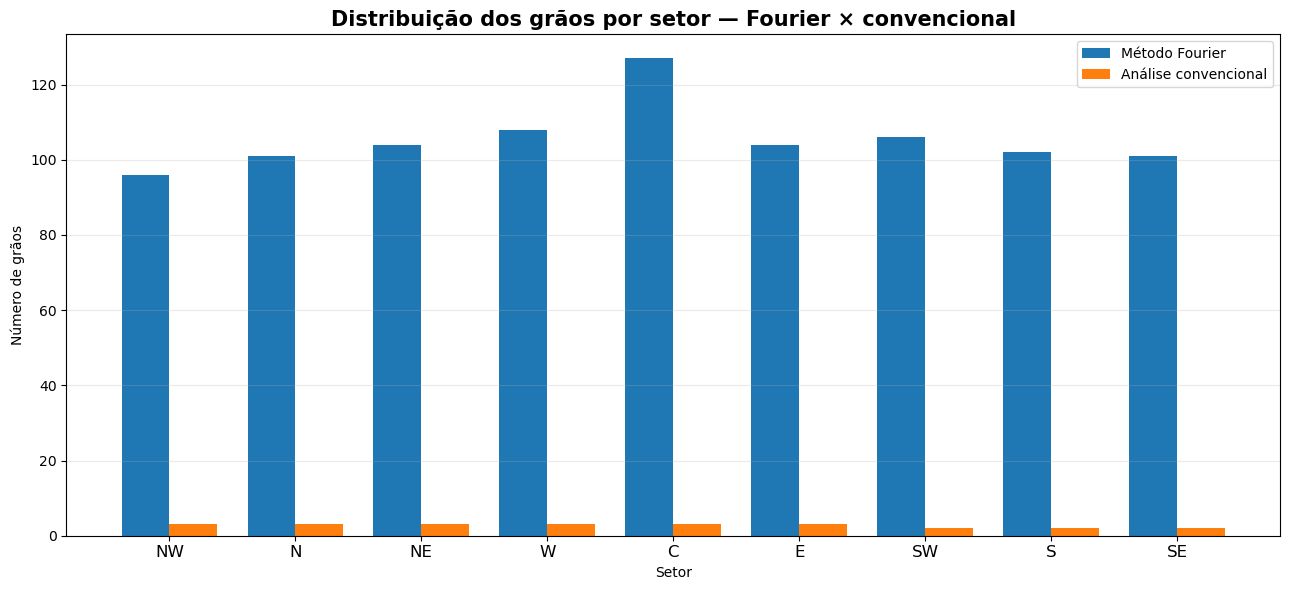

Figura salva: resultados_fourier_setorial/comparacao_contagem_setorial.png


In [57]:

# ============================================================
# 12. GRÁFICO COMPARATIVO DE CONTAGEM
# ============================================================

x = np.arange(len(sector_order))
bar_width = 0.38

fig, ax = plt.subplots(
    figsize=(13, 6)
)

ax.bar(
    x - bar_width/2,
    comparison["N_Fourier"],
    bar_width,
    label="Método Fourier"
)

ax.bar(
    x + bar_width/2,
    comparison["N_convencional"],
    bar_width,
    label="Análise convencional"
)

ax.set_xticks(x)
ax.set_xticklabels(
    sector_order,
    fontsize=12
)

ax.set_xlabel("Setor")
ax.set_ylabel("Número de grãos")

ax.set_title(
    "Distribuição dos grãos por setor — Fourier × convencional",
    fontsize=15,
    fontweight="bold"
)

ax.legend()
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()

comparison_plot = (
    OUTPUT_DIR /
    "comparacao_contagem_setorial.png"
)

fig.savefig(
    comparison_plot,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura salva:", comparison_plot)


In [58]:

# ============================================================
# 13. EXPORTAÇÃO CSV + EXCEL
# ============================================================

# Dados por grão sem arrays longos.
df_export = df.drop(
    columns=[
        "angles",
        "radii",
        "angles_smooth",
        "radii_smooth",
        "radii_fourier",
        "fourier_descriptors",
    ]
).copy()

df_export["Setor"] = df_export["Setor"].astype(str)

grain_csv = (
    OUTPUT_DIR /
    "resultados_por_grao.csv"
)

df_export.to_csv(
    grain_csv,
    index=False,
    encoding="utf-8-sig",
    float_format="%.8f"
)

# Descritores Fourier.
fourier_matrix = np.vstack(
    df["fourier_descriptors"].values
)

fourier_df = pd.DataFrame(
    fourier_matrix,
    columns=[
        f"D{i}"
        for i in range(fourier_matrix.shape[1])
    ]
)

fourier_df.insert(
    0,
    "grain_id",
    df["grain_id"].values
)

fourier_df.insert(
    1,
    "Setor",
    df["Setor"].astype(str).values
)

fourier_csv = (
    OUTPUT_DIR /
    "descritores_fourier.csv"
)

fourier_df.to_csv(
    fourier_csv,
    index=False,
    encoding="utf-8-sig",
    float_format="%.10f"
)

excel_path = (
    OUTPUT_DIR /
    "analise_fourier_setorial.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    df_export.to_excel(
        writer,
        sheet_name="Graos",
        index=False
    )

    fourier_df.to_excel(
        writer,
        sheet_name="Fourier",
        index=False
    )

    sector_mean.to_excel(
        writer,
        sheet_name="Setorial_Medias"
    )

    comparison.to_excel(
        writer,
        sheet_name="Comparacao"
    )

    conventional.to_excel(
        writer,
        sheet_name="Convencional",
        index=False
    )

print("Arquivos:")
print("CSV:", grain_csv)
print("Fourier:", fourier_csv)
print("Excel:", excel_path)


Arquivos:
CSV: resultados_fourier_setorial/resultados_por_grao.csv
Fourier: resultados_fourier_setorial/descritores_fourier.csv
Excel: resultados_fourier_setorial/analise_fourier_setorial.xlsx


In [59]:

# ============================================================
# 14. RELATÓRIO PDF
# ============================================================

pdf_path = (
    OUTPUT_DIR /
    "relatorio_fourier_setorial.pdf"
)

with PdfPages(pdf_path) as pdf:

    # Página 1 — resumo
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.axis("off")

    summary = [
        ["Parâmetro", "Valor"],
        ["Dimensão", f"{height} × {width} px"],
        ["Grãos analisados", str(len(df))],
        ["Escala", f"{CONFIG['px_to_um']} µm/px"],
        ["Harmônicos", f"{CONFIG['min_harmonics']}–{CONFIG['max_harmonics']}"],
        ["Descritores Fourier", str(CONFIG["n_fourier_descriptors"])],
    ]

    table = ax.table(
        cellText=summary,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2)

    ax.set_title(
        "Resumo da análise Fourier",
        fontsize=16,
        fontweight="bold"
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Página 2 — grade
    fig, ax = plt.subplots(figsize=(12, 8))

    ax.imshow(
        mask,
        cmap="gray",
        origin="upper"
    )

    ax.axvline(x1, linewidth=2)
    ax.axvline(x2, linewidth=2)
    ax.axhline(y1, linewidth=2)
    ax.axhline(y2, linewidth=2)

    for sector, (sx, sy) in positions.items():
        n = int(sector_counts.loc[sector])

        ax.text(
            sx,
            sy,
            f"{sector}\nN={n}",
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                alpha=0.75
            )
        )

    ax.set_title(
        "Divisão espacial 3 × 3",
        fontsize=16,
        fontweight="bold"
    )
    ax.axis("off")

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Página 3 — tabela
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.axis("off")

    table_data = (
        sector_mean
        .round(4)
        .reset_index()
    )

    table = ax.table(
        cellText=table_data.values,
        colLabels=table_data.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.7)

    ax.set_title(
        "Médias dos descritores por setor",
        fontsize=15,
        fontweight="bold"
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    # Página 4 — comparação
    fig, ax = plt.subplots(figsize=(13, 6))

    ax.bar(
        x - bar_width/2,
        comparison["N_Fourier"],
        bar_width,
        label="Fourier"
    )

    ax.bar(
        x + bar_width/2,
        comparison["N_convencional"],
        bar_width,
        label="Convencional"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(sector_order)
    ax.set_ylabel("Número de grãos")
    ax.set_xlabel("Setor")
    ax.set_title(
        "Distribuição setorial — Fourier × convencional",
        fontweight="bold"
    )
    ax.legend()
    ax.grid(axis="y", alpha=0.25)

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print("PDF salvo:", pdf_path)


PDF salvo: resultados_fourier_setorial/relatorio_fourier_setorial.pdf


In [60]:

# ============================================================
# 15. VALIDAÇÃO FINAL
# ============================================================

checks = {
    "Máscara válida": mask.sum() > 0,
    "Grãos analisados": len(df) > 0,
    "IDs únicos": not df["grain_id"].duplicated().any(),
    "Sem NaN": not df[required_columns].isna().any().any(),
    "Centroides dentro da imagem": inside.all(),
    "Todos os grãos possuem setor": not df["Setor"].isna().any(),
    "Soma dos setores = total": int(sector_counts.sum()) == len(df),
}

print("="*70)
print("VALIDAÇÃO FINAL")
print("="*70)

for name, status in checks.items():
    print(("✓ " if status else "✗ ") + name)

if not all(checks.values()):
    raise RuntimeError(
        "Uma ou mais verificações falharam."
    )

print("\n" + "="*70)
print("PIPELINE CONCLUÍDO COM SUCESSO")
print("="*70)
print("Grãos:", len(df))
print("Setores:", len(sector_order))
print("Saída:", OUTPUT_DIR.resolve())

print("\nArquivos principais:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path.name)


VALIDAÇÃO FINAL
✓ Máscara válida
✓ Grãos analisados
✓ IDs únicos
✓ Sem NaN
✓ Centroides dentro da imagem
✓ Todos os grãos possuem setor
✓ Soma dos setores = total

PIPELINE CONCLUÍDO COM SUCESSO
Grãos: 949
Setores: 9
Saída: /home/victor/analise_sinais_2025/joelson/2LFST1AM/projeto/resultados_fourier_setorial

Arquivos principais:
 - analise_fourier_setorial.xlsx
 - comparacao_contagem_setorial.png
 - comparacao_setorial.csv
 - descritores_fourier.csv
 - lamina_grade_3x3.png
 - mapa_area.png
 - mapa_circularidade.png
 - mapa_harmonicos.png
 - mapa_r2.png
 - mapa_regularidade.png
 - mapa_roundness.png
 - relatorio_fourier_setorial.pdf
 - resultados_por_grao.csv
 - tabela_setorial_medias.csv


In [63]:
# ==========================================================
# 16. CLASSIFICAÇÃO MORFOLÓGICA DOS GRÃOS
# ==========================================================
#
# Objetivo:
#   1. Manter os valores numéricos dos descritores;
#   2. Classificar esfericidade em:
#        Alta / Média / Baixa
#   3. Classificar arredondamento em:
#        Arredondado / Subarredondado / Subangular / Outros
#   4. Gerar resultados individuais e setoriais;
#   5. Permitir comparação direta com a tabela
#      "ANÁLISE SETORIAL DE GRÃOS" da Faro 12.
#
# OBSERVAÇÃO:
#   Como a análise é realizada em imagens 2D, a "esfericidade"
#   abaixo é tratada como um PROXY GEOMÉTRICO 2D baseado na
#   circularidade.
# ==========================================================

print("=" * 80)
print("CLASSIFICAÇÃO MORFOLÓGICA DOS GRÃOS")
print("=" * 80)


# ==========================================================
# 1. VERIFICAR DATAFRAME
# ==========================================================

if "df" not in globals():
    raise RuntimeError(
        "O DataFrame 'df' não foi encontrado. "
        "Execute as células anteriores do pipeline."
    )

print(f"\nNúmero de grãos analisados: {len(df)}")

print("\nDescritores disponíveis:")
print([
    c for c in df.columns
    if c in [
        "roundness",
        "circularity",
        "regularity"
    ]
])


# ==========================================================
# 2. VERIFICAR DESCRITORES NECESSÁRIOS
# ==========================================================

coluna_arredondamento = "roundness"
coluna_esfericidade = "circularity"

colunas_necessarias = [
    coluna_arredondamento,
    coluna_esfericidade,
    "Setor"
]

faltantes = [
    c for c in colunas_necessarias
    if c not in df.columns
]

if faltantes:
    raise RuntimeError(
        f"Colunas necessárias ausentes no DataFrame: {faltantes}"
    )


# ==========================================================
# 3. GARANTIR TIPO NUMÉRICO
# ==========================================================

df["roundness"] = pd.to_numeric(
    df["roundness"],
    errors="coerce"
)

df["circularity"] = pd.to_numeric(
    df["circularity"],
    errors="coerce"
)


# ==========================================================
# 4. LIMITES DE CLASSIFICAÇÃO
# ==========================================================
#
# Os limites são parâmetros explícitos do modelo.
#
# Para a análise 2D:
#
#   circularity -> proxy de esfericidade
#   roundness   -> arredondamento geométrico
#
# Estes limites NÃO são valores retirados da descrição
# convencional da Faro 12.
#
# Eles devem ser posteriormente calibrados com uma amostra
# de referência caso se deseje uma validação quantitativa
# rigorosa contra a classificação petrográfica.
# ==========================================================

# -------- ESFERICIDADE --------
#
# circularidade:
#
# >= 0.75 -> Alta
# >= 0.50 -> Média
# <  0.50 -> Baixa
#

LIMIAR_ESFERICIDADE_ALTA = 0.75
LIMIAR_ESFERICIDADE_MEDIA = 0.50


# -------- ARREDONDAMENTO --------
#
# roundness:
#
# >= 0.75 -> Arredondado
# >= 0.50 -> Subarredondado
# >= 0.35 -> Subangular
# <  0.35 -> Outros
#

LIMIAR_ARREDONDADO = 0.75
LIMIAR_SUBARREDONDADO = 0.50
LIMIAR_SUBANGULAR = 0.35


# ==========================================================
# 5. FUNÇÃO — ESFERICIDADE
# ==========================================================

def classificar_esfericidade(valor):

    if pd.isna(valor):
        return "Não classificado"

    if valor >= LIMIAR_ESFERICIDADE_ALTA:
        return "Alta"

    elif valor >= LIMIAR_ESFERICIDADE_MEDIA:
        return "Média"

    else:
        return "Baixa"


# ==========================================================
# 6. FUNÇÃO — ARREDONDAMENTO
# ==========================================================

def classificar_arredondamento(valor):

    if pd.isna(valor):
        return "Não classificado"

    if valor >= LIMIAR_ARREDONDADO:
        return "Arredondado"

    elif valor >= LIMIAR_SUBARREDONDADO:
        return "Subarredondado"

    elif valor >= LIMIAR_SUBANGULAR:
        return "Subangular"

    else:
        return "Outros"


# ==========================================================
# 7. CLASSIFICAÇÃO INDIVIDUAL DOS GRÃOS
# ==========================================================

df["Esfericidade_numerica"] = (
    df["circularity"]
)

df["Esfericidade"] = (
    df["Esfericidade_numerica"]
    .apply(classificar_esfericidade)
)

df["Arredondamento_numerico"] = (
    df["roundness"]
)

df["Arredondamento"] = (
    df["Arredondamento_numerico"]
    .apply(classificar_arredondamento)
)


# ==========================================================
# 8. RESULTADO INDIVIDUAL
# ==========================================================

colunas_resultado = [
    "grain_id",
    "Setor",
    "Esfericidade_numerica",
    "Esfericidade",
    "Arredondamento_numerico",
    "Arredondamento",
    "circularity",
    "roundness",
    "regularity"
]

colunas_resultado = [
    c for c in colunas_resultado
    if c in df.columns
]

resultado_morfologico = (
    df[colunas_resultado]
    .copy()
)


print("\n" + "=" * 80)
print("RESULTADO MORFOLÓGICO POR GRÃO")
print("=" * 80)

display(
    resultado_morfologico
    .head(20)
    .round(4)
)


# ==========================================================
# 9. DISTRIBUIÇÃO GERAL — ESFERICIDADE
# ==========================================================

classes_esfericidade = [
    "Alta",
    "Média",
    "Baixa",
    "Não classificado"
]

contagem_esfericidade = (
    df["Esfericidade"]
    .value_counts()
    .reindex(
        classes_esfericidade,
        fill_value=0
    )
)

percentual_esfericidade = (
    contagem_esfericidade
    / len(df)
    * 100
).round(2)

tabela_esfericidade_geral = pd.DataFrame({
    "N": contagem_esfericidade,
    "Percentual (%)": percentual_esfericidade
})

print("\n" + "=" * 80)
print("ESFERICIDADE — DISTRIBUIÇÃO GERAL")
print("=" * 80)

display(tabela_esfericidade_geral)


# ==========================================================
# 10. DISTRIBUIÇÃO GERAL — ARREDONDAMENTO
# ==========================================================

classes_arredondamento = [
    "Arredondado",
    "Subarredondado",
    "Subangular",
    "Outros",
    "Não classificado"
]

contagem_arredondamento = (
    df["Arredondamento"]
    .value_counts()
    .reindex(
        classes_arredondamento,
        fill_value=0
    )
)

percentual_arredondamento = (
    contagem_arredondamento
    / len(df)
    * 100
).round(2)

tabela_arredondamento_geral = pd.DataFrame({
    "N": contagem_arredondamento,
    "Percentual (%)": percentual_arredondamento
})

print("\n" + "=" * 80)
print("ARREDONDAMENTO — DISTRIBUIÇÃO GERAL")
print("=" * 80)

display(tabela_arredondamento_geral)


# ==========================================================
# 11. ESFERICIDADE POR SETOR
# ==========================================================

tabela_esfericidade_setorial = pd.crosstab(
    df["Setor"],
    df["Esfericidade"]
)

tabela_esfericidade_setorial = (
    tabela_esfericidade_setorial
    .reindex(
        index=sector_order,
        columns=classes_esfericidade,
        fill_value=0
    )
)

print("\n" + "=" * 80)
print("ESFERICIDADE POR SETOR — N")
print("=" * 80)

display(tabela_esfericidade_setorial)


# ==========================================================
# 12. ESFERICIDADE POR SETOR — PERCENTUAL
# ==========================================================

tabela_esfericidade_setorial_pct = (
    tabela_esfericidade_setorial
    .div(
        tabela_esfericidade_setorial.sum(axis=1),
        axis=0
    )
    * 100
)

tabela_esfericidade_setorial_pct = (
    tabela_esfericidade_setorial_pct
    .round(2)
)

print("\n" + "=" * 80)
print("ESFERICIDADE POR SETOR — %")
print("=" * 80)

display(tabela_esfericidade_setorial_pct)


# ==========================================================
# 13. ARREDONDAMENTO POR SETOR
# ==========================================================

tabela_arredondamento_setorial = pd.crosstab(
    df["Setor"],
    df["Arredondamento"]
)

tabela_arredondamento_setorial = (
    tabela_arredondamento_setorial
    .reindex(
        index=sector_order,
        columns=classes_arredondamento,
        fill_value=0
    )
)

print("\n" + "=" * 80)
print("ARREDONDAMENTO POR SETOR — N")
print("=" * 80)

display(tabela_arredondamento_setorial)


# ==========================================================
# 14. ARREDONDAMENTO POR SETOR — PERCENTUAL
# ==========================================================

tabela_arredondamento_setorial_pct = (
    tabela_arredondamento_setorial
    .div(
        tabela_arredondamento_setorial.sum(axis=1),
        axis=0
    )
    * 100
)

tabela_arredondamento_setorial_pct = (
    tabela_arredondamento_setorial_pct
    .round(2)
)

print("\n" + "=" * 80)
print("ARREDONDAMENTO POR SETOR — %")
print("=" * 80)

display(tabela_arredondamento_setorial_pct)


# ==========================================================
# 15. CLASSE DOMINANTE POR SETOR
# ==========================================================

classe_dominante_esfericidade = (
    tabela_esfericidade_setorial[
        ["Alta", "Média", "Baixa"]
    ]
    .idxmax(axis=1)
)

classe_dominante_arredondamento = (
    tabela_arredondamento_setorial[
        [
            "Arredondado",
            "Subarredondado",
            "Subangular",
            "Outros"
        ]
    ]
    .idxmax(axis=1)
)

resumo_setorial_morfologico = pd.DataFrame(
    index=sector_order
)

resumo_setorial_morfologico[
    "Esfericidade dominante"
] = classe_dominante_esfericidade

resumo_setorial_morfologico[
    "N Esfericidade dominante"
] = [
    tabela_esfericidade_setorial.loc[
        setor,
        classe_dominante_esfericidade.loc[setor]
    ]
    for setor in sector_order
]

resumo_setorial_morfologico[
    "Arredondamento dominante"
] = classe_dominante_arredondamento

resumo_setorial_morfologico[
    "N Arredondamento dominante"
] = [
    tabela_arredondamento_setorial.loc[
        setor,
        classe_dominante_arredondamento.loc[setor]
    ]
    for setor in sector_order
]


print("\n" + "=" * 80)
print("RESUMO MORFOLÓGICO POR SETOR")
print("=" * 80)

display(resumo_setorial_morfologico)


# ==========================================================
# 16. TABELA FINAL PARA COMPARAÇÃO COM A ANÁLISE
#    CONVENCIONAL DA FARO 12
# ==========================================================

comparacao_morfologica = pd.DataFrame(
    index=sector_order
)

comparacao_morfologica[
    "Esfericidade Fourier — dominante"
] = (
    classe_dominante_esfericidade
)

comparacao_morfologica[
    "Arredondamento Fourier — dominante"
] = (
    classe_dominante_arredondamento
)

comparacao_morfologica[
    "Roundness média"
] = (
    df.groupby(
        "Setor",
        observed=False
    )["roundness"]
    .mean()
    .reindex(sector_order)
)

comparacao_morfologica[
    "Circularidade média"
] = (
    df.groupby(
        "Setor",
        observed=False
    )["circularity"]
    .mean()
    .reindex(sector_order)
)


print("\n" + "=" * 80)
print("TABELA FINAL — FOURIER × ANÁLISE CONVENCIONAL")
print("=" * 80)

display(
    comparacao_morfologica.round(4)
)


# ==========================================================
# 17. EXPORTAÇÃO
# ==========================================================

resultado_morfologico.to_csv(
    OUTPUT_DIR / "classificacao_morfologica_por_grao.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_esfericidade_setorial.to_csv(
    OUTPUT_DIR / "esfericidade_setorial_N.csv",
    encoding="utf-8-sig"
)

tabela_esfericidade_setorial_pct.to_csv(
    OUTPUT_DIR / "esfericidade_setorial_percentual.csv",
    encoding="utf-8-sig"
)

tabela_arredondamento_setorial.to_csv(
    OUTPUT_DIR / "arredondamento_setorial_N.csv",
    encoding="utf-8-sig"
)

tabela_arredondamento_setorial_pct.to_csv(
    OUTPUT_DIR / "arredondamento_setorial_percentual.csv",
    encoding="utf-8-sig"
)

comparacao_morfologica.to_csv(
    OUTPUT_DIR / "comparacao_morfologica_fourier.csv",
    encoding="utf-8-sig"
)


print("\n" + "=" * 80)
print("CLASSIFICAÇÃO MORFOLÓGICA CONCLUÍDA")
print("=" * 80)

print("\nArquivos gerados:")

print(
    " - classificacao_morfologica_por_grao.csv"
)

print(
    " - esfericidade_setorial_N.csv"
)

print(
    " - esfericidade_setorial_percentual.csv"
)

print(
    " - arredondamento_setorial_N.csv"
)

print(
    " - arredondamento_setorial_percentual.csv"
)

print(
    " - comparacao_morfologica_fourier.csv"
)

CLASSIFICAÇÃO MORFOLÓGICA DOS GRÃOS

Número de grãos analisados: 949

Descritores disponíveis:
['roundness', 'circularity', 'regularity']

RESULTADO MORFOLÓGICO POR GRÃO


,grain_id,Setor,Esfericidade_numerica,Esfericidade,Arredondamento_numerico,Arredondamento,circularity,roundness,regularity
0,1,NE,0.6165,Média,0.7852,Arredondado,0.6165,0.7852,3.4553
1,2,NE,0.4613,Baixa,0.6792,Subarredondado,0.4613,0.6792,1.9572
2,3,N,0.6101,Média,0.7811,Arredondado,0.6101,0.7811,2.7623
3,4,NE,0.4873,Baixa,0.6980,Subarredondado,0.4873,0.6980,2.7966
4,5,N,0.8533,Alta,0.9237,Arredondado,0.8533,0.9237,4.6241
5,6,NW,0.5843,Média,0.7644,Arredondado,0.5843,0.7644,2.8676
6,7,N,0.8053,Alta,0.8974,Arredondado,0.8053,0.8974,0.0000
7,8,NE,0.6551,Média,0.8094,Arredondado,0.6551,0.8094,3.0515
8,9,N,0.7378,Média,0.8589,Arredondado,0.7378,0.8589,4.4269
9,10,NW,0.6407,Média,0.8004,Arredondado,0.6407,0.8004,3.0170



ESFERICIDADE — DISTRIBUIÇÃO GERAL


,N,Percentual (%)
Alta,223,23.50
Média,556,58.59
Baixa,170,17.91
Não classificado,0,0.00



ARREDONDAMENTO — DISTRIBUIÇÃO GERAL


...


RESUMO MORFOLÓGICO POR SETOR


,Esfericidade dominante,N Esfericidade dominante,Arredondamento dominante,N Arredondamento dominante
NW,Média,59,Arredondado,69
N,Média,57,Arredondado,75
NE,Média,57,Arredondado,72
W,Média,63,Arredondado,67
C,Média,73,Arredondado,93
E,Média,68,Arredondado,70
SW,Média,69,Arredondado,78
S,Média,54,Arredondado,72
SE,Média,56,Arredondado,67



TABELA FINAL — FOURIER × ANÁLISE CONVENCIONAL


,Esfericidade Fourier — dominante,Arredondamento Fourier — dominante,Roundness média,Circularidade média
NW,Média,Arredondado,0.8033,0.6539
N,Média,Arredondado,0.8043,0.6539
NE,Média,Arredondado,0.7921,0.6388
W,Média,Arredondado,0.7727,0.6090
C,Média,Arredondado,0.8001,0.6488
E,Média,Arredondado,0.7918,0.6350
SW,Média,Arredondado,0.8085,0.6643
S,Média,Arredondado,0.7910,0.6385
SE,Média,Arredondado,0.7867,0.6305



CLASSIFICAÇÃO MORFOLÓGICA CONCLUÍDA

Arquivos gerados:
 - classificacao_morfologica_por_grao.csv
 - esfericidade_setorial_N.csv
 - esfericidade_setorial_percentual.csv
 - arredondamento_setorial_N.csv
 - arredondamento_setorial_percentual.csv
 - comparacao_morfologica_fourier.csv


COMPARAÇÃO SETORIAL — FARO 12 × FOURIER

Número total de grãos no CSV: 949
Grãos na análise convencional: 24

TABELA PRINCIPAL — COMPARAÇÃO POR SETOR


,N convencional,N Fourier,Esfericidade convencional,Esfericidade Fourier,Esfericidade média convencional,Esfericidade média Fourier,Arredondamento convencional,Arredondamento Fourier,Arredondamento médio convencional,Arredondamento médio Fourier
NW,3,96,Alta,Média,2.6667,0.6539,Subarredondado,Arredondado,2.6667,0.8033
N,3,101,Média,Média,1.6667,0.6539,Subangular,Arredondado,2.3333,0.8043
NE,3,104,Alta,Média,2.6667,0.6388,Arredondado,Arredondado,3.6667,0.7921
W,3,108,Média,Média,2.0000,0.6090,Subarredondado,Arredondado,2.6667,0.7727
C,3,127,Média,Média,2.3333,0.6488,Subangular,Arredondado,2.3333,0.8001
E,3,104,Alta,Média,2.6667,0.6350,Subarredondado,Arredondado,3.0000,0.7918
SW,2,106,Média,Média,1.5000,0.6643,Subarredondado,Arredondado,2.5000,0.8085
S,2,102,Alta,Média,2.5000,0.6385,Subarredondado,Arredondado,2.5000,0.7910
SE,2,101,Alta,Média,2.0000,0.6305,Arredondado,Arredondado,3.0000,0.7867



ESFERICIDADE — COMPARAÇÃO SETORIAL


,N convencional,N Fourier,Média convencional (índice 1–3),Média Fourier (0–1),Classe dominante convencional,Classe dominante Fourier
NW,3,96,2.6667,0.6539,Alta,Média
N,3,101,1.6667,0.6539,Média,Média
NE,3,104,2.6667,0.6388,Alta,Média
W,3,108,2.0000,0.6090,Média,Média
C,3,127,2.3333,0.6488,Média,Média
E,3,104,2.6667,0.6350,Alta,Média
SW,2,106,1.5000,0.6643,Média,Média
S,2,102,2.5000,0.6385,Alta,Média
SE,2,101,2.0000,0.6305,Alta,Média



ARREDONDAMENTO — COMPARAÇÃO SETORIAL


,N convencional,N Fourier,Média convencional (índice 1–4),Média Fourier (0–1),Classe dominante convencional,Classe dominante Fourier
NW,3,96,2.6667,0.8033,Subarredondado,Arredondado
N,3,101,2.3333,0.8043,Subangular,Arredondado
NE,3,104,3.6667,0.7921,Arredondado,Arredondado
W,3,108,2.6667,0.7727,Subarredondado,Arredondado
C,3,127,2.3333,0.8001,Subangular,Arredondado
E,3,104,3.0000,0.7918,Subarredondado,Arredondado
SW,2,106,2.5000,0.8085,Subarredondado,Arredondado
S,2,102,2.5000,0.7910,Subarredondado,Arredondado
SE,2,101,3.0000,0.7867,Arredondado,Arredondado


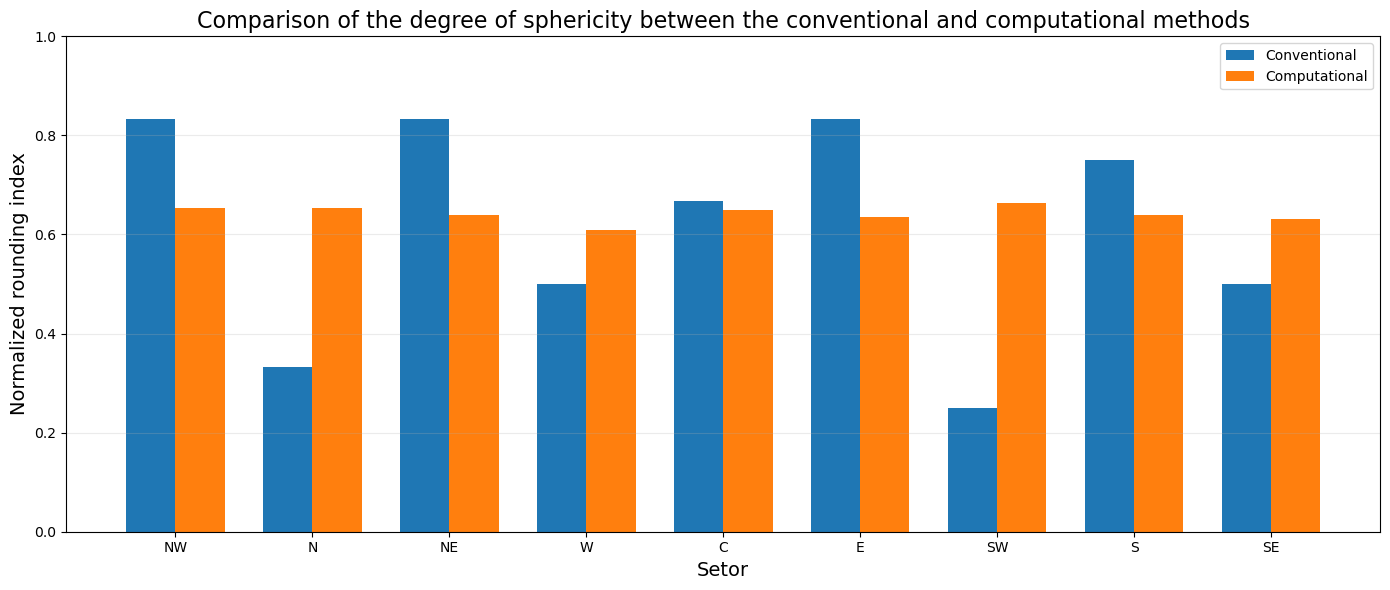

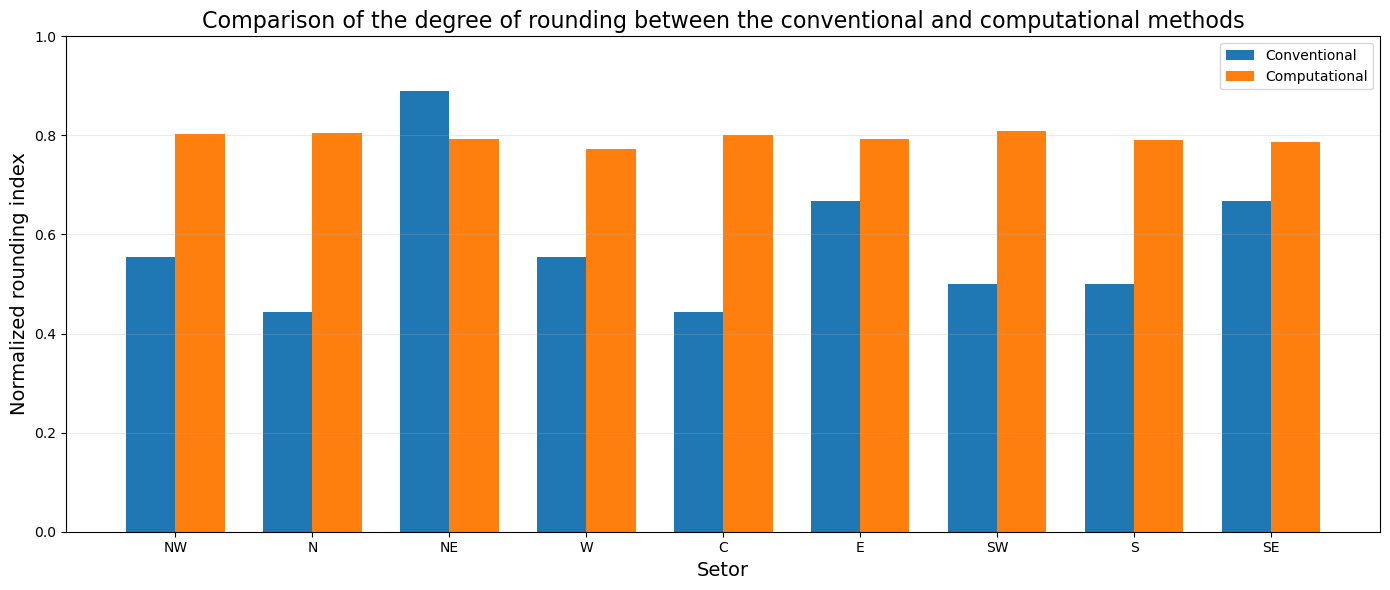


COMPARAÇÃO CONCLUÍDA


In [75]:
# ============================================================
# COMPARAÇÃO SETORIAL:
# ANÁLISE CONVENCIONAL FARO 12 × MÉTODO FOURIER
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. CONFIGURAÇÕES
# ------------------------------------------------------------

SETORES = ["NW", "N", "NE", "W", "C", "E", "SW", "S", "SE"]

CSV_FOURIER = OUTPUT_DIR / "classificacao_morfologica_por_grao.csv"


# ------------------------------------------------------------
# 2. CARREGAR RESULTADOS DO FOURIER
# ------------------------------------------------------------

df_fourier = pd.read_csv(CSV_FOURIER)

print("=" * 80)
print("COMPARAÇÃO SETORIAL — FARO 12 × FOURIER")
print("=" * 80)

print(f"\nNúmero total de grãos no CSV: {len(df_fourier)}")


# ------------------------------------------------------------
# 3. VERIFICAÇÃO DAS COLUNAS
# ------------------------------------------------------------

colunas_necessarias = [
    "Setor",
    "Esfericidade_numerica",
    "Esfericidade",
    "Arredondamento_numerico",
    "Arredondamento"
]

faltantes = [
    c for c in colunas_necessarias
    if c not in df_fourier.columns
]

if faltantes:
    raise ValueError(
        f"As seguintes colunas estão ausentes no CSV: {faltantes}"
    )


# ------------------------------------------------------------
# 4. TABELA CONVENCIONAL DA FARO 12
# ------------------------------------------------------------
#
# Dados transcritos da seção:
# "ANÁLISE SETORIAL DE GRÃOS"
#
# da descrição petrográfica da Faro 12.
# ------------------------------------------------------------

dados_convencional = [

    # NW
    ["NW", "Qz mono", 0.18, "Alta",  "Subarredondado"],
    ["NW", "Qz mono", 0.12, "Média", "Subangular"],
    ["NW", "Qz mono", 0.25, "Alta",  "Subarredondado"],

    # N
    ["N", "Qz mono",   0.30, "Média", "Subarredondado"],
    ["N", "Feldspato", 0.22, "Média", "Subangular"],
    ["N", "Qz poli",   0.20, "Baixa", "Subangular"],

    # NE
    ["NE", "Qz mono", 0.15, "Alta",  "Arredondado"],
    ["NE", "Opaco",   0.10, "Alta",  "Arredondado"],
    ["NE", "Qz mono", 0.35, "Média", "Subarredondado"],

    # W
    ["W", "Qz mono", 0.20, "Média", "Subarredondado"],
    ["W", "Lítico",  0.28, "Baixa", "Subangular"],
    ["W", "Qz mono", 0.14, "Alta", "Subarredondado"],

    # C
    ["C", "Qz mono",   0.22, "Alta",  "Subarredondado"],
    ["C", "Qz mono",   0.16, "Média", "Subangular"],
    ["C", "Feldspato", 0.18, "Média", "Subangular"],

    # E
    ["E", "Qz mono", 0.25, "Alta",  "Subarredondado"],
    ["E", "Qz mono", 0.12, "Média", "Subangular"],
    ["E", "Opaco",   0.08, "Alta",  "Arredondado"],

    # SW
    ["SW", "Qz mono", 0.20, "Média", "Subarredondado"],
    ["SW", "Qz poli", 0.30, "Baixa", "Subangular"],

    # S
    ["S", "Qz mono", 0.18, "Alta",  "Subarredondado"],
    ["S", "Qz mono", 0.15, "Média", "Subangular"],

    # SE
    ["SE", "Qz mono", 0.22, "Alta", "Arredondado"],
    ["SE", "Lítico",  0.20, "Baixa", "Subangular"],
]


df_conv = pd.DataFrame(
    dados_convencional,
    columns=[
        "Setor",
        "Mineral",
        "Tam_mm",
        "Esfericidade",
        "Arredondamento"
    ]
)

print(f"Grãos na análise convencional: {len(df_conv)}")


# ------------------------------------------------------------
# 5. MAPAS ORDINAIS
# ------------------------------------------------------------

mapa_esfericidade = {
    "Baixa": 1,
    "Média": 2,
    "Alta": 3
}

mapa_arredondamento = {
    "Outros": 1,
    "Subangular": 2,
    "Subarredondado": 3,
    "Arredondado": 4
}


# ------------------------------------------------------------
# 6. CONVERSÃO DAS CLASSES CONVENCIONAIS PARA ÍNDICES
# ------------------------------------------------------------

df_conv["Esfericidade_indice"] = (
    df_conv["Esfericidade"]
    .map(mapa_esfericidade)
)

df_conv["Arredondamento_indice"] = (
    df_conv["Arredondamento"]
    .map(mapa_arredondamento)
)


# ------------------------------------------------------------
# 7. MÉDIAS DA ANÁLISE CONVENCIONAL POR SETOR
# ------------------------------------------------------------

conv_setorial = (
    df_conv
    .groupby("Setor")
    .agg(
        N_convencional=("Mineral", "size"),
        Esfericidade_media_indice=(
            "Esfericidade_indice",
            "mean"
        ),
        Arredondamento_media_indice=(
            "Arredondamento_indice",
            "mean"
        ),
        Tamanho_medio_mm=("Tam_mm", "mean")
    )
    .reindex(SETORES)
)


# ------------------------------------------------------------
# 8. MÉDIAS DO FOURIER POR SETOR
# ------------------------------------------------------------

fourier_setorial = (
    df_fourier
    .groupby("Setor", observed=False)
    .agg(
        N_fourier=("Setor", "size"),
        Esfericidade_media=(
            "Esfericidade_numerica",
            "mean"
        ),
        Arredondamento_media=(
            "Arredondamento_numerico",
            "mean"
        )
    )
    .reindex(SETORES)
)


# ------------------------------------------------------------
# 9. CLASSE DOMINANTE — CONVENCIONAL
# ------------------------------------------------------------

esf_dominante_conv = (
    df_conv
    .groupby("Setor")["Esfericidade"]
    .agg(
        lambda x: x.value_counts().idxmax()
    )
    .reindex(SETORES)
)

arr_dominante_conv = (
    df_conv
    .groupby("Setor")["Arredondamento"]
    .agg(
        lambda x: x.value_counts().idxmax()
    )
    .reindex(SETORES)
)


# ------------------------------------------------------------
# 10. CLASSE DOMINANTE — FOURIER
# ------------------------------------------------------------

esf_dominante_fourier = (
    df_fourier
    .groupby("Setor", observed=False)["Esfericidade"]
    .agg(
        lambda x: x.value_counts().idxmax()
    )
    .reindex(SETORES)
)

arr_dominante_fourier = (
    df_fourier
    .groupby("Setor", observed=False)["Arredondamento"]
    .agg(
        lambda x: x.value_counts().idxmax()
    )
    .reindex(SETORES)
)


# ------------------------------------------------------------
# 11. TABELA PRINCIPAL DE COMPARAÇÃO
# ------------------------------------------------------------

comparacao = pd.DataFrame(index=SETORES)

comparacao["N convencional"] = (
    conv_setorial["N_convencional"]
)

comparacao["N Fourier"] = (
    fourier_setorial["N_fourier"]
)

comparacao["Esfericidade convencional"] = (
    esf_dominante_conv
)

comparacao["Esfericidade Fourier"] = (
    esf_dominante_fourier
)

comparacao["Esfericidade média convencional"] = (
    conv_setorial["Esfericidade_media_indice"]
)

comparacao["Esfericidade média Fourier"] = (
    fourier_setorial["Esfericidade_media"]
)

comparacao["Arredondamento convencional"] = (
    arr_dominante_conv
)

comparacao["Arredondamento Fourier"] = (
    arr_dominante_fourier
)

comparacao["Arredondamento médio convencional"] = (
    conv_setorial["Arredondamento_media_indice"]
)

comparacao["Arredondamento médio Fourier"] = (
    fourier_setorial["Arredondamento_media"]
)


print("\n" + "=" * 80)
print("TABELA PRINCIPAL — COMPARAÇÃO POR SETOR")
print("=" * 80)

display(
    comparacao.round(4)
)


# ------------------------------------------------------------
# 12. TABELA ESPECÍFICA — ESFERICIDADE
# ------------------------------------------------------------

tabela_esfericidade = pd.DataFrame(index=SETORES)

tabela_esfericidade["N convencional"] = (
    conv_setorial["N_convencional"]
)

tabela_esfericidade["N Fourier"] = (
    fourier_setorial["N_fourier"]
)

tabela_esfericidade[
    "Média convencional (índice 1–3)"
] = (
    conv_setorial["Esfericidade_media_indice"]
)

tabela_esfericidade[
    "Média Fourier (0–1)"
] = (
    fourier_setorial["Esfericidade_media"]
)

tabela_esfericidade[
    "Classe dominante convencional"
] = esf_dominante_conv

tabela_esfericidade[
    "Classe dominante Fourier"
] = esf_dominante_fourier


print("\n" + "=" * 80)
print("ESFERICIDADE — COMPARAÇÃO SETORIAL")
print("=" * 80)

display(
    tabela_esfericidade.round(4)
)


# ------------------------------------------------------------
# 13. TABELA ESPECÍFICA — ARREDONDAMENTO
# ------------------------------------------------------------

tabela_arredondamento = pd.DataFrame(index=SETORES)

tabela_arredondamento["N convencional"] = (
    conv_setorial["N_convencional"]
)

tabela_arredondamento["N Fourier"] = (
    fourier_setorial["N_fourier"]
)

tabela_arredondamento[
    "Média convencional (índice 1–4)"
] = (
    conv_setorial["Arredondamento_media_indice"]
)

tabela_arredondamento[
    "Média Fourier (0–1)"
] = (
    fourier_setorial["Arredondamento_media"]
)

tabela_arredondamento[
    "Classe dominante convencional"
] = arr_dominante_conv

tabela_arredondamento[
    "Classe dominante Fourier"
] = arr_dominante_fourier


print("\n" + "=" * 80)
print("ARREDONDAMENTO — COMPARAÇÃO SETORIAL")
print("=" * 80)

display(
    tabela_arredondamento.round(4)
)


# ============================================================
# 14. NORMALIZAÇÃO PARA COMPARAÇÃO GRÁFICA
# ============================================================
#
# Para colocar as duas metodologias na MESMA escala:
#
# Esfericidade:
#   1 -> 0
#   2 -> 0.5
#   3 -> 1
#
# Arredondamento:
#   1 -> 0
#   2 -> 0.333
#   3 -> 0.667
#   4 -> 1
#
# Assim:
#
#   Fourier      = descritor numérico 0–1
#   Convencional = índice ordinal normalizado 0–1
#
# IMPORTANTE:
# Esta normalização é apenas para comparação visual/ordinal.
# Não significa que a escala petrográfica convencional seja
# fisicamente equivalente ao descritor Fourier.
# ============================================================

comparacao_grafico = pd.DataFrame(index=SETORES)

comparacao_grafico[
    "Esfericidade — Convencional"
] = (
    (conv_setorial["Esfericidade_media_indice"] - 1) / 2
)

comparacao_grafico[
    "Esfericidade — Fourier"
] = (
    fourier_setorial["Esfericidade_media"]
)

comparacao_grafico[
    "Arredondamento — Convencional"
] = (
    (conv_setorial["Arredondamento_media_indice"] - 1) / 3
)

comparacao_grafico[
    "Arredondamento — Fourier"
] = (
    fourier_setorial["Arredondamento_media"]
)


# ============================================================
# 15. GRÁFICO — ESFERICIDADE
# ============================================================

x = np.arange(len(SETORES))
largura = 0.36

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.bar(
    x - largura / 2,
    comparacao_grafico[
        "Esfericidade — Convencional"
    ],
    width=largura,
    label="Conventional"
)

ax.bar(
    x + largura / 2,
    comparacao_grafico[
        "Esfericidade — Fourier"
    ],
    width=largura,
    label="Computational"
)

ax.set_xticks(x)
ax.set_xticklabels(SETORES)

ax.set_ylim(0, 1)

ax.set_xlabel("Setor", fontsize=14)
ax.set_ylabel(
    "Normalized rounding index", fontsize=14
)

ax.set_title(
    "Comparison of the degree of sphericity between the conventional and computational methods", fontsize=16
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# 16. GRÁFICO — ARREDONDAMENTO
# ============================================================

fig, ax = plt.subplots(
    figsize=(14, 6)
)

ax.bar(
    x - largura / 2,
    comparacao_grafico[
        "Arredondamento — Convencional"
    ],
    width=largura,
    label="Conventional"
)

ax.bar(
    x + largura / 2,
    comparacao_grafico[
        "Arredondamento — Fourier"
    ],
    width=largura,
    label="Computational"
)

ax.set_xticks(x)
ax.set_xticklabels(SETORES)

ax.set_ylim(0, 1)

ax.set_xlabel("Setor", fontsize= 14)
ax.set_ylabel(
    "Normalized rounding index", fontsize= 14
)

ax.set_title(
    "Comparison of the degree of rounding between the conventional and computational methods", fontsize=16
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()


# ============================================================
# 17. TABELA FINAL PARA EXPORTAÇÃO
# ============================================================

comparacao.to_csv(
    OUTPUT_DIR /
    "comparacao_setorial_convencional_fourier.csv",
    encoding="utf-8-sig"
)

tabela_esfericidade.to_csv(
    OUTPUT_DIR /
    "comparacao_esfericidade_setorial.csv",
    encoding="utf-8-sig"
)

tabela_arredondamento.to_csv(
    OUTPUT_DIR /
    "comparacao_arredondamento_setorial.csv",
    encoding="utf-8-sig"
)

comparacao_grafico.to_csv(
    OUTPUT_DIR /
    "comparacao_grafica_normalizada.csv",
    encoding="utf-8-sig"
)


print("\n" + "=" * 80)
print("COMPARAÇÃO CONCLUÍDA")
print("=" * 80) 